In [ ]:
import numpy as np
from utils.fcfd_unpacker import FCFD_unpacker
from utils.fcfd_time_reconstruction import time_reconstruction
import matplotlib.pyplot as plt
import mplhep as hep
plt.style.use([hep.style.ROOT, hep.style.firamath])

In [16]:
config = {}
config["tdc_encoder"]=0
unpacker = FCFD_unpacker(config)
import json
with open("./test_result/test_time_scan_10.00001MHz_TDC0.json", "r") as json_file:
    data = json.load(json_file)["raw_data"]
packages =  unpacker.parse_to_dataframes(data)
x = []
ts = []
for i,p in enumerate(packages):
    parsed = unpacker.parse_dataframe(p)
    tdc = parsed['tdc'][0]
    if tdc["ERR_CODE"]!=0:
        continue
    t = time_reconstruction(tdc['CLK_TAG'],8,tdc['CAL0'],tdc['CAL_SUM'],tdc['TOA0'],tdc['TOA_SUM'])
    ts.append(t)
    x.append(i)

for index in range(1, len(ts)):
    while ts[index] < ts[index - 1] - 20000:
        ts[index] += 25000

x = np.array(x)
ts = np.array(ts)

print(len(ts))

65536


In [17]:
T_10 = 1e5

T_new = 1e12 / (10.00001e6)

deltaT = abs(T_10 - T_new)



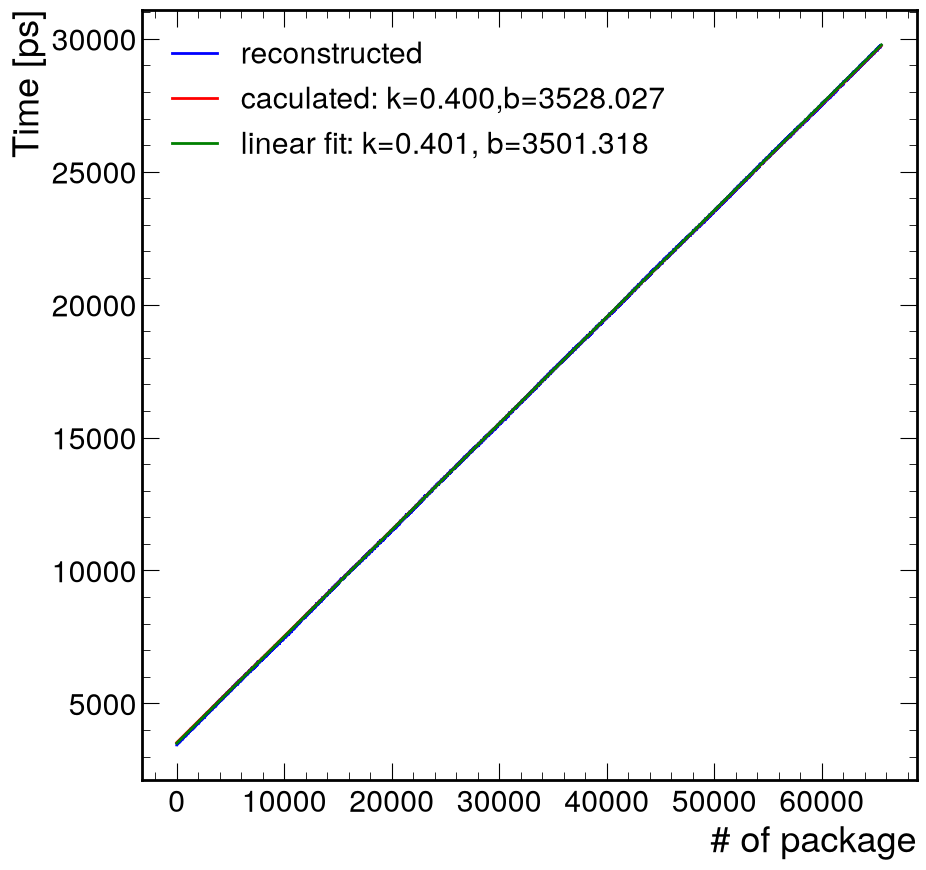

In [21]:
k, b = np.polyfit(x, ts, 1)
ts_linear = k * x + b

offset = np.mean(np.asarray(ts) - 4 * x * deltaT)
ts_ = offset + 4 * x * deltaT

plt.plot(x, ts, color='blue', linewidth=2, label='reconstructed')
plt.plot(x, ts_, color="red", linewidth=2, label=f'caculated: k={4*deltaT:.3f},b={offset:.3f}')
plt.plot(x, ts_linear, color="green", linewidth=2, label=f"linear fit: k={k:.3f}, b={b:.3f}")
plt.xlabel("# of package")
plt.ylabel("Time [ps]")
plt.legend()



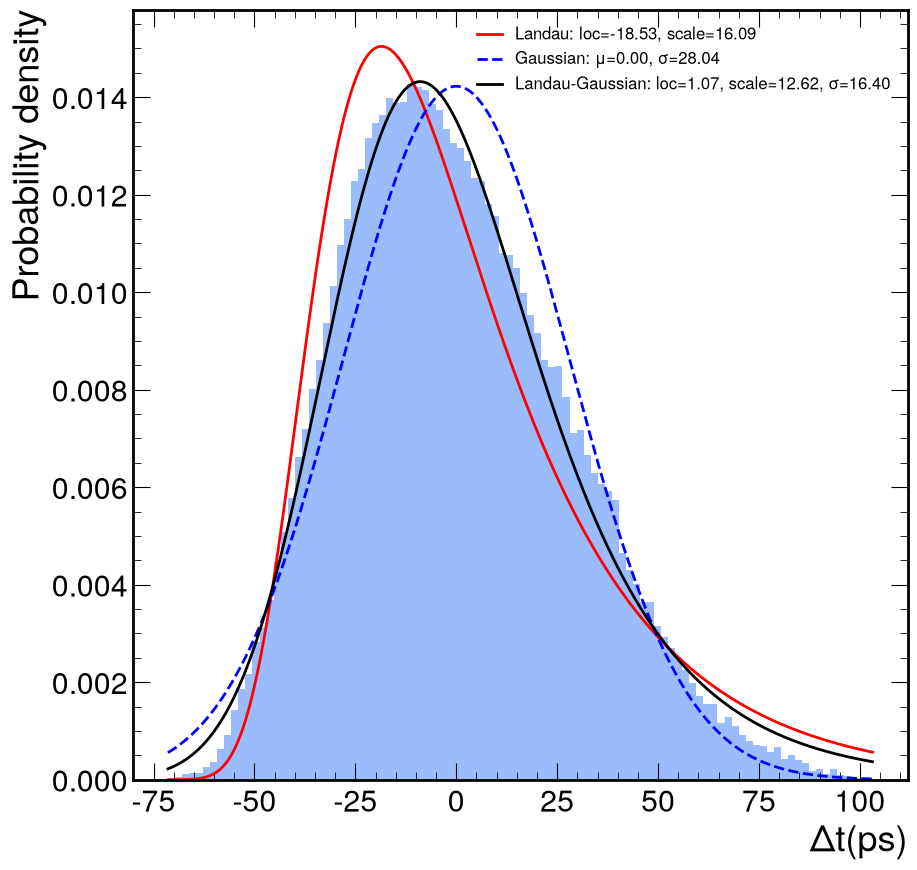

In [ ]:
from scipy.optimize import curve_fit
from scipy.signal import fftconvolve
from scipy.stats import moyal, norm

residuals = np.asarray(ts_ - ts)
landau_loc, landau_scale = moyal.fit(residuals)
gauss_mu, gauss_sigma = norm.fit(residuals)

counts, bins, _ = plt.hist(residuals, 100, density=True, alpha=0.6)
bin_centers = (bins[:-1] + bins[1:]) / 2
x_fit = np.linspace(bins[0], bins[-1], 500)

fit_grid = np.linspace(
    bins[0] - 6 * (bins[-1] - bins[0]),
    bins[-1] + 6 * (bins[-1] - bins[0]),
    4096,
)
fit_step = fit_grid[1] - fit_grid[0]


def landau_gauss_pdf(x, loc, landau_scale, gauss_sigma):
    landau = moyal.pdf(fit_grid, loc=loc, scale=landau_scale)
    gaussian = norm.pdf(fit_grid, loc=0, scale=gauss_sigma)
    convolution = fftconvolve(landau, gaussian, mode="same") * fit_step
    return np.interp(x, fit_grid, convolution, left=0, right=0)


initial_guess = [landau_loc, landau_scale, gauss_sigma]
fit_parameters, _ = curve_fit(
    landau_gauss_pdf,
    bin_centers,
    counts,
    p0=initial_guess,
    bounds=([-np.inf, 1e-9, 1e-9], [np.inf, np.inf, np.inf]),
    maxfev=10000,
)
lg_loc, lg_landau_scale, lg_gauss_sigma = fit_parameters

plt.plot(
    x_fit,
    moyal.pdf(x_fit, loc=landau_loc, scale=landau_scale),
    "r-",
    linewidth=2,
    label=f"Landau: loc={landau_loc:.2f}, scale={landau_scale:.2f}",
)
plt.plot(
    x_fit,
    norm.pdf(x_fit, loc=gauss_mu, scale=gauss_sigma),
    "b--",
    linewidth=2,
    label=f"Gaussian: $\\mu$={gauss_mu:.2f}, $\\sigma$={gauss_sigma:.2f}",
)
plt.plot(
    x_fit,
    landau_gauss_pdf(x_fit, *fit_parameters),
    "k-",
    linewidth=2,
    label=(
        f"Landau-Gaussian: loc={lg_loc:.2f}, "
        f"scale={lg_landau_scale:.2f}, $\\sigma$={lg_gauss_sigma:.2f}"
    ),
)
plt.xlabel(r"$\Delta t$(ps)")
plt.ylabel("Probability density")
plt.legend(loc="upper right", fontsize = 12)

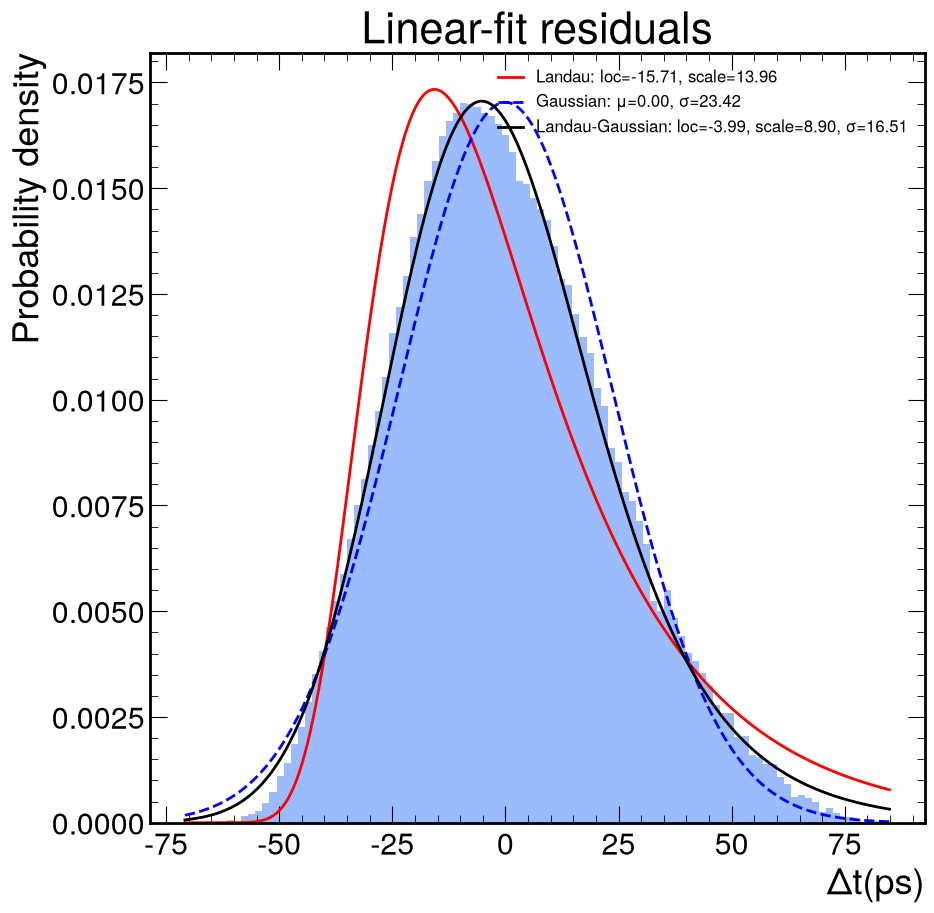

In [20]:
from scipy.optimize import curve_fit
from scipy.signal import fftconvolve
from scipy.stats import moyal, norm

linear_residuals = np.asarray(ts_linear - ts)
linear_landau_loc, linear_landau_scale = moyal.fit(linear_residuals)
linear_gauss_mu, linear_gauss_sigma = norm.fit(linear_residuals)

plt.figure()
linear_counts, linear_bins, _ = plt.hist(
    linear_residuals, 100, density=True, alpha=0.6
)
linear_bin_centers = (linear_bins[:-1] + linear_bins[1:]) / 2
linear_x_fit = np.linspace(linear_bins[0], linear_bins[-1], 500)
linear_fit_grid = np.linspace(
    linear_bins[0] - 6 * (linear_bins[-1] - linear_bins[0]),
    linear_bins[-1] + 6 * (linear_bins[-1] - linear_bins[0]),
    4096,
)
linear_fit_step = linear_fit_grid[1] - linear_fit_grid[0]


def linear_landau_gauss_pdf(x, loc, landau_scale, gauss_sigma):
    landau = moyal.pdf(linear_fit_grid, loc=loc, scale=landau_scale)
    gaussian = norm.pdf(linear_fit_grid, loc=0, scale=gauss_sigma)
    convolution = fftconvolve(landau, gaussian, mode="same") * linear_fit_step
    return np.interp(x, linear_fit_grid, convolution, left=0, right=0)


linear_fit_parameters, _ = curve_fit(
    linear_landau_gauss_pdf,
    linear_bin_centers,
    linear_counts,
    p0=[linear_landau_loc, linear_landau_scale, linear_gauss_sigma],
    bounds=([-np.inf, 1e-9, 1e-9], [np.inf, np.inf, np.inf]),
    maxfev=10000,
)
linear_lg_loc, linear_lg_landau_scale, linear_lg_gauss_sigma = linear_fit_parameters

plt.plot(
    linear_x_fit,
    moyal.pdf(
        linear_x_fit,
        loc=linear_landau_loc,
        scale=linear_landau_scale,
    ),
    "r-",
    linewidth=2,
    label=(
        f"Landau: loc={linear_landau_loc:.2f}, "
        f"scale={linear_landau_scale:.2f}"
    ),
)
plt.plot(
    linear_x_fit,
    norm.pdf(
        linear_x_fit,
        loc=linear_gauss_mu,
        scale=linear_gauss_sigma,
    ),
    "b--",
    linewidth=2,
    label=(
        f"Gaussian: $\\mu$={linear_gauss_mu:.2f}, "
        f"$\\sigma$={linear_gauss_sigma:.2f}"
    ),
)
plt.plot(
    linear_x_fit,
    linear_landau_gauss_pdf(linear_x_fit, *linear_fit_parameters),
    "k-",
    linewidth=2,
    label=(
        f"Landau-Gaussian: loc={linear_lg_loc:.2f}, "
        f"scale={linear_lg_landau_scale:.2f}, "
        f"$\\sigma$={linear_lg_gauss_sigma:.2f}"
    ),
)
plt.xlabel(r"$\Delta t$(ps)")
plt.ylabel("Probability density")
plt.title("Linear-fit residuals")
plt.legend(loc="upper right", fontsize=12)